# Post 2 — Supplementary Analysis

This notebook covers analyses that were not completed in the main notebooks:

1. **Root-cause analysis of TabPFN direct-Tweedie holdout catastrophe**
2. **Wilcoxon signed-rank tests** (spec §8.1 — only t-test was run)
3. **CV-to-holdout generalization gap** across all models
4. **Auction by risk segment** — detailed decile breakdown plots
5. **Feature engineering value** — raw vs engineered vs GBM features
6. **Gini vs Deviance rank disagreement** — the 'benchmarks lie' story
7. **Post-hoc recalibration of TabPFN direct predictions** (partial)
8. **Summary table** ready for blog post

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Auto-discovers every TabPFN experiment subdir (results/post2/cv/<EXPERIMENT_ID>/, ...)
# so this notebook consumes all TabPFN library versions at once. Baseline models
# keep plain names; experiment models are tagged `<model>@<experiment_id>`.
from src.evaluation.experiment_io import (
    discover_experiments, load_all_cv, load_oof,
    load_all_holdout_metrics, load_all_holdout_predictions, tag, split_tag,
)

ROOT = Path(project_root)
RESULTS = ROOT / 'results' / 'post2'
FIGURES = ROOT / 'figures' / 'post2'
FIGURES.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = discover_experiments(project_root, 'cv')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('Setup complete')
print(f'TabPFN experiments discovered: {EXPERIMENTS or "(none yet)"}')


Setup complete
TabPFN experiments discovered: ['tabpfn_v2.6', 'tabpfn_v3.0']


## 1. Load All CV Fold Metrics

In [2]:
# Load every CV fold-metrics file: baselines (flat results/post2/cv/) + all experiment
# subdirs. Keys: plain stems for baselines, `<stem>@<experiment_id>` for experiments.
cv_data = {k: v['fold_metrics'] for k, v in load_all_cv(project_root).items()}

# Build summary dataframe
rows = []
for model, folds in cv_data.items():
    tw = [f.get('tweedie_dev_1.5', f.get('tweedie_dev', np.nan)) for f in folds]
    gi = [f.get('gini', np.nan) for f in folds]
    po = [f.get('poisson_dev', np.nan) for f in folds]
    rows.append({
        'model': model,
        'cv_tweedie_mean': np.nanmean(tw),
        'cv_tweedie_std': np.nanstd(tw),
        'cv_gini_mean': np.nanmean(gi),
        'cv_gini_std': np.nanstd(gi),
        'cv_poisson_mean': np.nanmean(po),
        'fold_tw': tw,
        'fold_gi': gi,
    })

cv_summary = pd.DataFrame(rows).sort_values('cv_tweedie_mean')
cv_summary[['model','cv_tweedie_mean','cv_tweedie_std','cv_gini_mean','cv_gini_std']]


,model,cv_tweedie_mean,cv_tweedie_std,cv_gini_mean,cv_gini_std
5,LightGBM_gbm_tweedie,79.548574,2.726375e+00,0.434316,0.093641
7,LightGBM_raw_tweedie,80.085709,2.300434e+00,0.400119,0.079149
23,TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0,80.683826,3.169586e+00,0.579315,0.063602
16,TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6,81.220988,3.920853e+00,0.568962,0.070321
6,LightGBM_hurdle_gbm_hurdle,81.563213,1.986808e+00,0.380995,0.097629
22,TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0,82.754763,1.977805e+00,0.290974,0.154768
15,TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6,82.919118,2.310018e+00,0.387408,0.063444
4,LightGBM_engineered_tweedie,83.634731,3.950403e+00,0.419310,0.072776
3,GLM_hurdle_gbm_hurdle,85.155091,2.206140e+00,0.364339,0.101857
10,XGBoost_hurdle_gbm_hurdle,86.100328,2.600544e+00,0.309091,0.093764


## 2. Wilcoxon Signed-Rank Tests (spec §8.1)

The spec requires both paired t-test AND Wilcoxon signed-rank test. The main notebook only ran t-tests.

In [3]:
def paired_comparison(fold_metrics_a, fold_metrics_b, name_a, name_b, metric='tweedie_dev_1.5'):
    """
    Paired t-test + Wilcoxon on 5 CV fold values.
    With n=5 the tests have low power; Wilcoxon is more appropriate.
    """
    a_vals = np.array([f.get(metric, f.get('tweedie_dev', np.nan)) for f in fold_metrics_a])
    b_vals = np.array([f.get(metric, f.get('tweedie_dev', np.nan)) for f in fold_metrics_b])
    diffs = a_vals - b_vals

    # Paired t-test
    t_stat, t_p = stats.ttest_rel(a_vals, b_vals)

    # Wilcoxon (requires n>=4 with no zeros; handle gracefully)
    try:
        w_stat, w_p = stats.wilcoxon(a_vals, b_vals, alternative='two-sided')
    except ValueError as e:
        w_stat, w_p = np.nan, np.nan

    # 95% CI on difference via bootstrap
    boot_diffs = [np.mean(np.random.choice(diffs, len(diffs), replace=True)) for _ in range(5000)]
    ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])

    return {
        'model_a': name_a,
        'model_b': name_b,
        'mean_a': np.mean(a_vals),
        'mean_b': np.mean(b_vals),
        'mean_diff': np.mean(diffs),
        'ci_95': (ci_lo, ci_hi),
        't_stat': t_stat,
        't_p': t_p,
        'w_stat': w_stat,
        'w_p': w_p,
        'a_better_folds': int((a_vals < b_vals).sum()),  # lower = better for deviance
        'a_vals': a_vals.tolist(),
        'b_vals': b_vals.tolist(),
    }


# Baseline-vs-baseline matchup is fixed; every TabPFN matchup is built once per
# discovered experiment, plus cross-version matchups between consecutive experiments.
key_matchups = [
    ('LightGBM_gbm_tweedie', 'GLM_Tweedie_raw_tweedie', 'LightGBM_gbm', 'GLM_Tweedie_raw'),
]
for exp in EXPERIMENTS:
    H_full  = tag('TabPFN_hurdle_full_gbm_hurdle', exp)
    H_cg    = tag('TabPFN_hurdle_cls_gamma_gbm_hurdle', exp)
    T10_gbm = tag('TabPFN_10K_gbm_tweedie', exp)
    T10_raw = tag('TabPFN_10K_raw_tweedie', exp)
    key_matchups += [
        ('LightGBM_gbm_tweedie', H_full,  'LightGBM_gbm',              f'TabPFN_hurdle_full[{exp}]'),
        ('LightGBM_gbm_tweedie', H_cg,    'LightGBM_gbm',              f'TabPFN_hurdle_cls_gamma[{exp}]'),
        (H_full,  T10_gbm,                f'TabPFN_hurdle_full[{exp}]', f'TabPFN_10K_gbm[{exp}]'),
        (H_full,  'GLM_Tweedie_raw_tweedie', f'TabPFN_hurdle_full[{exp}]', 'GLM_Tweedie_raw'),
        (H_full,  'GLM_hurdle_gbm_hurdle',   f'TabPFN_hurdle_full[{exp}]', 'GLM_hurdle_gbm'),
        ('LightGBM_gbm_tweedie', T10_gbm, 'LightGBM_gbm',              f'TabPFN_10K_gbm[{exp}]'),
        (T10_gbm, T10_raw,                f'TabPFN_10K_gbm[{exp}]',     f'TabPFN_10K_raw[{exp}]'),
        (T10_gbm, 'GLM_Tweedie_raw_tweedie', f'TabPFN_10K_gbm[{exp}]',  'GLM_Tweedie_raw'),
    ]
# Cross-version: same TabPFN model across consecutive experiments.
for exp_a, exp_b in zip(EXPERIMENTS, EXPERIMENTS[1:]):
    for model, short in [('TabPFN_hurdle_full_gbm_hurdle', 'TabPFN_hurdle_full'),
                         ('TabPFN_10K_gbm_tweedie', 'TabPFN_10K_gbm')]:
        key_matchups.append((tag(model, exp_a), tag(model, exp_b),
                             f'{short}[{exp_a}]', f'{short}[{exp_b}]'))

comparison_results = []
for key_a, key_b, name_a, name_b in key_matchups:
    if key_a in cv_data and key_b in cv_data:
        r = paired_comparison(cv_data[key_a], cv_data[key_b], name_a, name_b)
        comparison_results.append(r)

comp_df = pd.DataFrame([
    {
        'Matchup': f"{r['model_a']} vs {r['model_b']}",
        'Mean A': f"{r['mean_a']:.2f}",
        'Mean B': f"{r['mean_b']:.2f}",
        'Mean Δ (A−B)': f"{r['mean_diff']:+.2f}",
        '95% CI': f"[{r['ci_95'][0]:+.2f}, {r['ci_95'][1]:+.2f}]",
        't-test p': f"{r['t_p']:.4f}",
        'Wilcoxon p': f"{r['w_p']:.4f}" if not np.isnan(r['w_p']) else 'N/A',
        'A wins (folds)': f"{r['a_better_folds']}/5",
    }
    for r in comparison_results
])

print("Paired comparisons (CV, 5 folds) — Tweedie deviance, lower is better")
print("A wins folds = number of folds where A < B (lower deviance)\n")
pd.set_option('display.max_colwidth', 60)
display(comp_df)


Paired comparisons (CV, 5 folds) — Tweedie deviance, lower is better
A wins folds = number of folds where A < B (lower deviance)



,Matchup,Mean A,Mean B,Mean Δ (A−B),95% CI,t-test p,Wilcoxon p,A wins (folds)
0,LightGBM_gbm vs GLM_Tweedie_raw,79.55,89.51,-9.96,"[-12.54, -8.44]",0.0015,0.0625,5/5
1,LightGBM_gbm vs TabPFN_hurdle_full[tabpfn_v2.6],79.55,81.22,-1.67,"[-4.25, +1.13]",0.3400,0.4375,3/5
2,LightGBM_gbm vs TabPFN_hurdle_cls_gamma[tabpfn_v2.6],79.55,82.92,-3.37,"[-6.79, -0.89]",0.1219,0.0625,5/5
3,TabPFN_hurdle_full[tabpfn_v2.6] vs TabPFN_10K_gbm[tabpfn...,81.22,90.19,-8.96,"[-13.26, -4.67]",0.0224,0.0625,5/5
4,TabPFN_hurdle_full[tabpfn_v2.6] vs GLM_Tweedie_raw,81.22,89.51,-8.29,"[-10.05, -6.44]",0.0016,0.0625,5/5
5,TabPFN_hurdle_full[tabpfn_v2.6] vs GLM_hurdle_gbm,81.22,85.16,-3.93,"[-5.94, -1.39]",0.0412,0.1250,4/5
6,LightGBM_gbm vs TabPFN_10K_gbm[tabpfn_v2.6],79.55,90.19,-10.64,"[-17.22, -4.78]",0.0395,0.0625,5/5
7,TabPFN_10K_gbm[tabpfn_v2.6] vs TabPFN_10K_raw[tabpfn_v2.6],90.19,91.56,-1.38,"[-3.01, +0.02]",0.1868,0.3125,4/5
8,TabPFN_10K_gbm[tabpfn_v2.6] vs GLM_Tweedie_raw,90.19,89.51,+0.68,"[-3.66, +5.01]",0.8032,0.8125,3/5
9,LightGBM_gbm vs TabPFN_10K_gbm[tabpfn_v3.0],79.55,99.09,-19.54,"[-27.34, -11.81]",0.0115,0.0625,5/5


## 3. CV-to-Holdout Generalization Gap

In [5]:
# Merge all holdout metrics: baselines (flat results/post2/holdout/) + every experiment
# subdir. Experiment rows are indexed `<model>@<experiment_id>`.
holdout_df = load_all_holdout_metrics(project_root)

# Build gap table — exclude TabPFN direct Tweedie (catastrophic)
gap_rows = []
cv_indexed = cv_summary.set_index('model')
for _, hrow in holdout_df.iterrows():
    model = hrow.name
    h_tw = hrow['tweedie_dev_1.5']
    h_gi = hrow['gini']

    if model in cv_indexed.index:
        cv_row = cv_indexed.loc[model]
        gap_rows.append({
            'model': model,
            'cv_tweedie': cv_row['cv_tweedie_mean'],
            'cv_tweedie_std': cv_row['cv_tweedie_std'],
            'holdout_tweedie': h_tw,
            'gap_tweedie': h_tw - cv_row['cv_tweedie_mean'],
            'cv_gini': cv_row['cv_gini_mean'],
            'holdout_gini': h_gi,
            'gap_gini': h_gi - cv_row['cv_gini_mean'],
        })

gap_df = pd.DataFrame(gap_rows)

# Filter out catastrophic TabPFN failures for the gap table
gap_df_clean = gap_df[gap_df['holdout_tweedie'] < 1000].sort_values('holdout_tweedie')
gap_df_flagged = gap_df[gap_df['holdout_tweedie'] >= 1000]

print("=== CV → Holdout Tweedie Deviance (clean models) ===")
display(gap_df_clean[['model','cv_tweedie','holdout_tweedie','gap_tweedie','cv_gini', 'holdout_gini', 'gap_gini']].round(3))

if len(gap_df_flagged) > 0:
    print("\n=== CATASTROPHIC HOLDOUT FAILURES ===")
    display(gap_df_flagged[['model','cv_tweedie','holdout_tweedie','gap_tweedie','cv_gini', 'holdout_gini', 'gap_gini']].round(2))


=== CV → Holdout Tweedie Deviance (clean models) ===


,model,cv_tweedie,holdout_tweedie,gap_tweedie,cv_gini,holdout_gini,gap_gini
17,TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0,82.755,81.722,-1.032,0.291,0.054,-0.237
7,LightGBM_gbm_tweedie,79.549,81.999,2.450,0.434,0.151,-0.284
13,TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6,82.919,82.057,-0.862,0.387,0.043,-0.344
5,LightGBM_raw_tweedie,80.086,82.288,2.202,0.400,0.127,-0.273
14,TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6,81.221,82.769,1.548,0.569,0.406,-0.163
10,LightGBM_hurdle_gbm_hurdle,81.563,82.883,1.320,0.381,0.081,-0.300
6,LightGBM_engineered_tweedie,83.635,83.127,-0.508,0.419,0.088,-0.331
18,TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0,80.684,83.129,2.445,0.579,0.425,-0.154
8,GLM_hurdle_gbm_hurdle,85.155,83.780,-1.375,0.364,0.079,-0.286
15,TabPFN_10K_raw_tweedie@tabpfn_v3.0,97.784,83.802,-13.981,0.392,0.234,-0.159



=== CATASTROPHIC HOLDOUT FAILURES ===


,model,cv_tweedie,holdout_tweedie,gap_tweedie,cv_gini,holdout_gini,gap_gini
11,TabPFN_10K_raw_tweedie@tabpfn_v2.6,91.56,59055523.26,59055431.70,0.25,0.06,-0.19
12,TabPFN_10K_gbm_tweedie@tabpfn_v2.6,90.19,56236126.75,56236036.57,0.28,0.05,-0.23
16,TabPFN_10K_uncalibrated_raw_tweedie@tabpfn_v3.0,784500.11,418024.95,-366475.16,0.39,0.23,-0.16


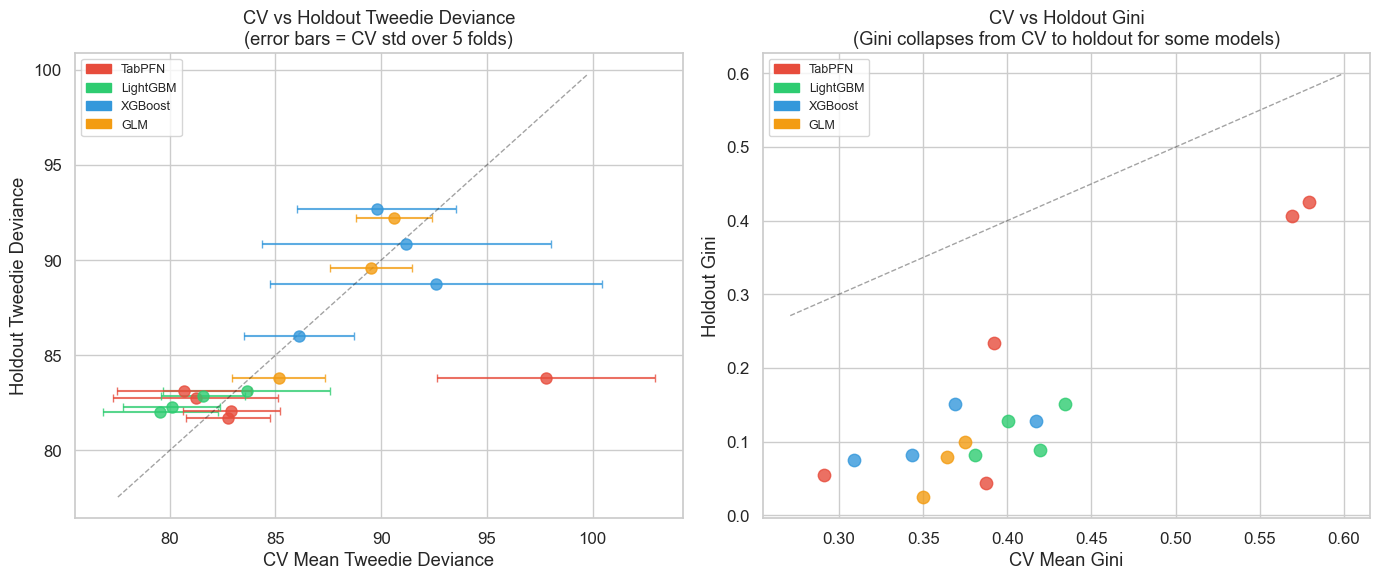

Saved.


In [26]:
# Plot: CV vs Holdout Tweedie deviance (scatter + identity line)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Colour by model family
def model_family(name):
    if 'TabPFN' in name: return 'TabPFN'
    elif 'LightGBM' in name: return 'LightGBM'
    elif 'XGBoost' in name: return 'XGBoost'
    else: return 'GLM'

palette = {'TabPFN': '#e74c3c', 'LightGBM': '#2ecc71', 'XGBoost': '#3498db', 'GLM': '#f39c12'}

# Tweedie deviance scatter
for _, row in gap_df_clean.iterrows():
    fam = model_family(row['model'])
    ax1.errorbar(
        row['cv_tweedie'], row['holdout_tweedie'],
        xerr=row['cv_tweedie_std'],
        fmt='o', color=palette[fam], markersize=8, alpha=0.8, capsize=3
    )

lo = gap_df_clean['cv_tweedie'].min() - 2
hi = gap_df_clean[['cv_tweedie','holdout_tweedie']].max().max() + 2
ax1.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.4, label='y = x')
ax1.set_xlabel('CV Mean Tweedie Deviance')
ax1.set_ylabel('Holdout Tweedie Deviance')
ax1.set_title('CV vs Holdout Tweedie Deviance\n(error bars = CV std over 5 folds)')

# Add legend patches
from matplotlib.patches import Patch
handles = [Patch(color=v, label=k) for k, v in palette.items()]
ax1.legend(handles=handles, fontsize=9)

# Gini scatter
for _, row in gap_df_clean.iterrows():
    fam = model_family(row['model'])
    ax2.scatter(row['cv_gini'], row['holdout_gini'], color=palette[fam], s=80, alpha=0.8, zorder=3)

lo2 = gap_df_clean['cv_gini'].min() - 0.02
hi2 = gap_df_clean[['cv_gini','holdout_gini']].max().max() + 0.02
ax2.plot([lo2, hi2], [lo2, hi2], 'k--', lw=1, alpha=0.4, label='y = x')
ax2.set_xlabel('CV Mean Gini')
ax2.set_ylabel('Holdout Gini')
ax2.set_title('CV vs Holdout Gini\n(Gini collapses from CV to holdout for some models)')
ax2.legend(handles=handles, fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'cv_vs_holdout_generalization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 5. Feature Engineering Value Analysis

In [6]:
# Compare raw vs engineered vs GBM feature set per model family.
# Baseline families are fixed; one TabPFN row is added per discovered experiment.
fe_comparison = [
    # (family, raw_key, eng_key, gbm_key)
    ('GLM',      'GLM_Tweedie_raw_tweedie',  'GLM_Tweedie_engineered_tweedie', None),
    ('XGBoost',  'XGBoost_raw_tweedie',      'XGBoost_engineered_tweedie',     'XGBoost_gbm_tweedie'),
    ('LightGBM', 'LightGBM_raw_tweedie',     'LightGBM_engineered_tweedie',    'LightGBM_gbm_tweedie'),
]
for exp in EXPERIMENTS:
    fe_comparison.append((
        f'TabPFN[{exp}]',
        tag('TabPFN_10K_raw_tweedie', exp),
        tag('TabPFN_10K_engineered_tweedie', exp),
        tag('TabPFN_10K_gbm_tweedie', exp),
    ))

cv_idx = cv_summary.set_index('model')
print(f"{'Family':<22} {'Raw CV':>10} {'Eng CV':>10} {'GBM CV':>10} {'Eng Δ':>9} {'GBM Δ':>9}")
print('-' * 75)
for fam, raw_k, eng_k, gbm_k in fe_comparison:
    raw_v = cv_idx.loc[raw_k, 'cv_tweedie_mean'] if raw_k in cv_idx.index else np.nan
    eng_v = cv_idx.loc[eng_k, 'cv_tweedie_mean'] if eng_k and eng_k in cv_idx.index else np.nan
    gbm_v = cv_idx.loc[gbm_k, 'cv_tweedie_mean'] if gbm_k and gbm_k in cv_idx.index else np.nan
    eng_d = eng_v - raw_v if not np.isnan(eng_v) else np.nan
    gbm_d = gbm_v - raw_v if not np.isnan(gbm_v) else np.nan
    print(f"{fam:<22} {raw_v:>10.2f} {eng_v:>10.2f} {gbm_v:>10.2f} {eng_d:>+9.2f} {gbm_d:>+9.2f}")


Family                     Raw CV     Eng CV     GBM CV     Eng Δ     GBM Δ
---------------------------------------------------------------------------
GLM                         89.51      90.61        nan     +1.10      +nan
XGBoost                     89.78      92.58      91.19     +2.80     +1.42
LightGBM                    80.09      83.63      79.55     +3.55     -0.54
TabPFN[tabpfn_v2.6]         91.56      92.10      90.19     +0.53     -1.38
TabPFN[tabpfn_v3.0]         97.78     100.32      99.09     +2.54     +1.30


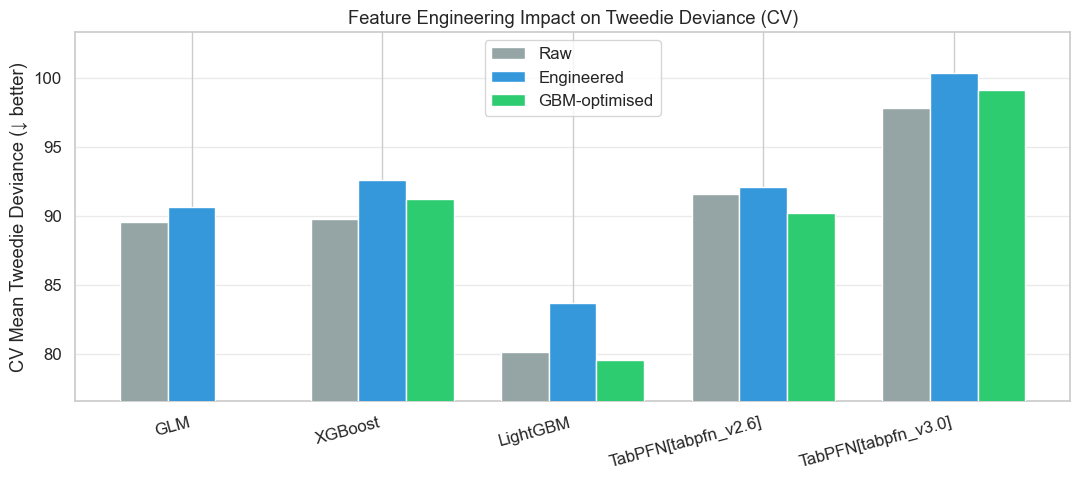

In [7]:
# Visualise feature engineering impact — reuses fe_comparison + cv_idx from above.
fig, ax = plt.subplots(figsize=(max(10, 2.2 * len(fe_comparison)), 5))

families, raw_vals, eng_vals, gbm_vals = [], [], [], []
for fam, raw_k, eng_k, gbm_k in fe_comparison:
    families.append(fam)
    raw_vals.append(cv_idx.loc[raw_k, 'cv_tweedie_mean'] if raw_k in cv_idx.index else np.nan)
    eng_vals.append(cv_idx.loc[eng_k, 'cv_tweedie_mean'] if eng_k and eng_k in cv_idx.index else np.nan)
    gbm_vals.append(cv_idx.loc[gbm_k, 'cv_tweedie_mean'] if gbm_k and gbm_k in cv_idx.index else np.nan)

x = np.arange(len(families))
w = 0.25
ax.bar(x - w, raw_vals, w, label='Raw',           color='#95a5a6', zorder=3)
ax.bar(x,     eng_vals, w, label='Engineered',    color='#3498db', zorder=3)
ax.bar(x + w, gbm_vals, w, label='GBM-optimised', color='#2ecc71', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(families, rotation=15, ha='right')
ax.set_ylabel('CV Mean Tweedie Deviance (↓ better)')
ax.set_title('Feature Engineering Impact on Tweedie Deviance (CV)')
ax.legend()
_finite = [v for v in raw_vals + eng_vals + gbm_vals if v == v]
if _finite:
    ax.set_ylim(min(_finite) - 3, max(_finite) + 3)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES / 'feature_engineering_impact.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Auction by Risk Segment — Detailed Decile Analysis

In [8]:
# auction_results.json is the consolidated, cross-experiment auction output
# regenerated by post2_analysis.ipynb (its run_all_auctions step writes it to
# results/post2/holdout/). Run post2_analysis.ipynb first if this file is missing.
auction_path = RESULTS / 'holdout' / 'auction_results.json'
if not auction_path.exists():
    raise FileNotFoundError(
        f"{auction_path} not found — run post2_analysis.ipynb first; its auction "
        "step regenerates the consolidated auction_results.json."
    )
with open(auction_path) as f:
    auction = json.load(f)

print("Available auction matchups:", list(auction.keys()))


Available auction matchups: ['TabPFN_best_vs_LightGBM_gbm', 'TabPFN_hurdle_vs_LightGBM_hurdle', 'TabPFN_best_vs_GLM_Tweedie_eng', 'XGBoost_gbm_vs_XGBoost_raw', 'TabPFN_hurdle_vs_TabPFN_10K_tweedie', 'LightGBM_hurdle_vs_LightGBM_gbm']


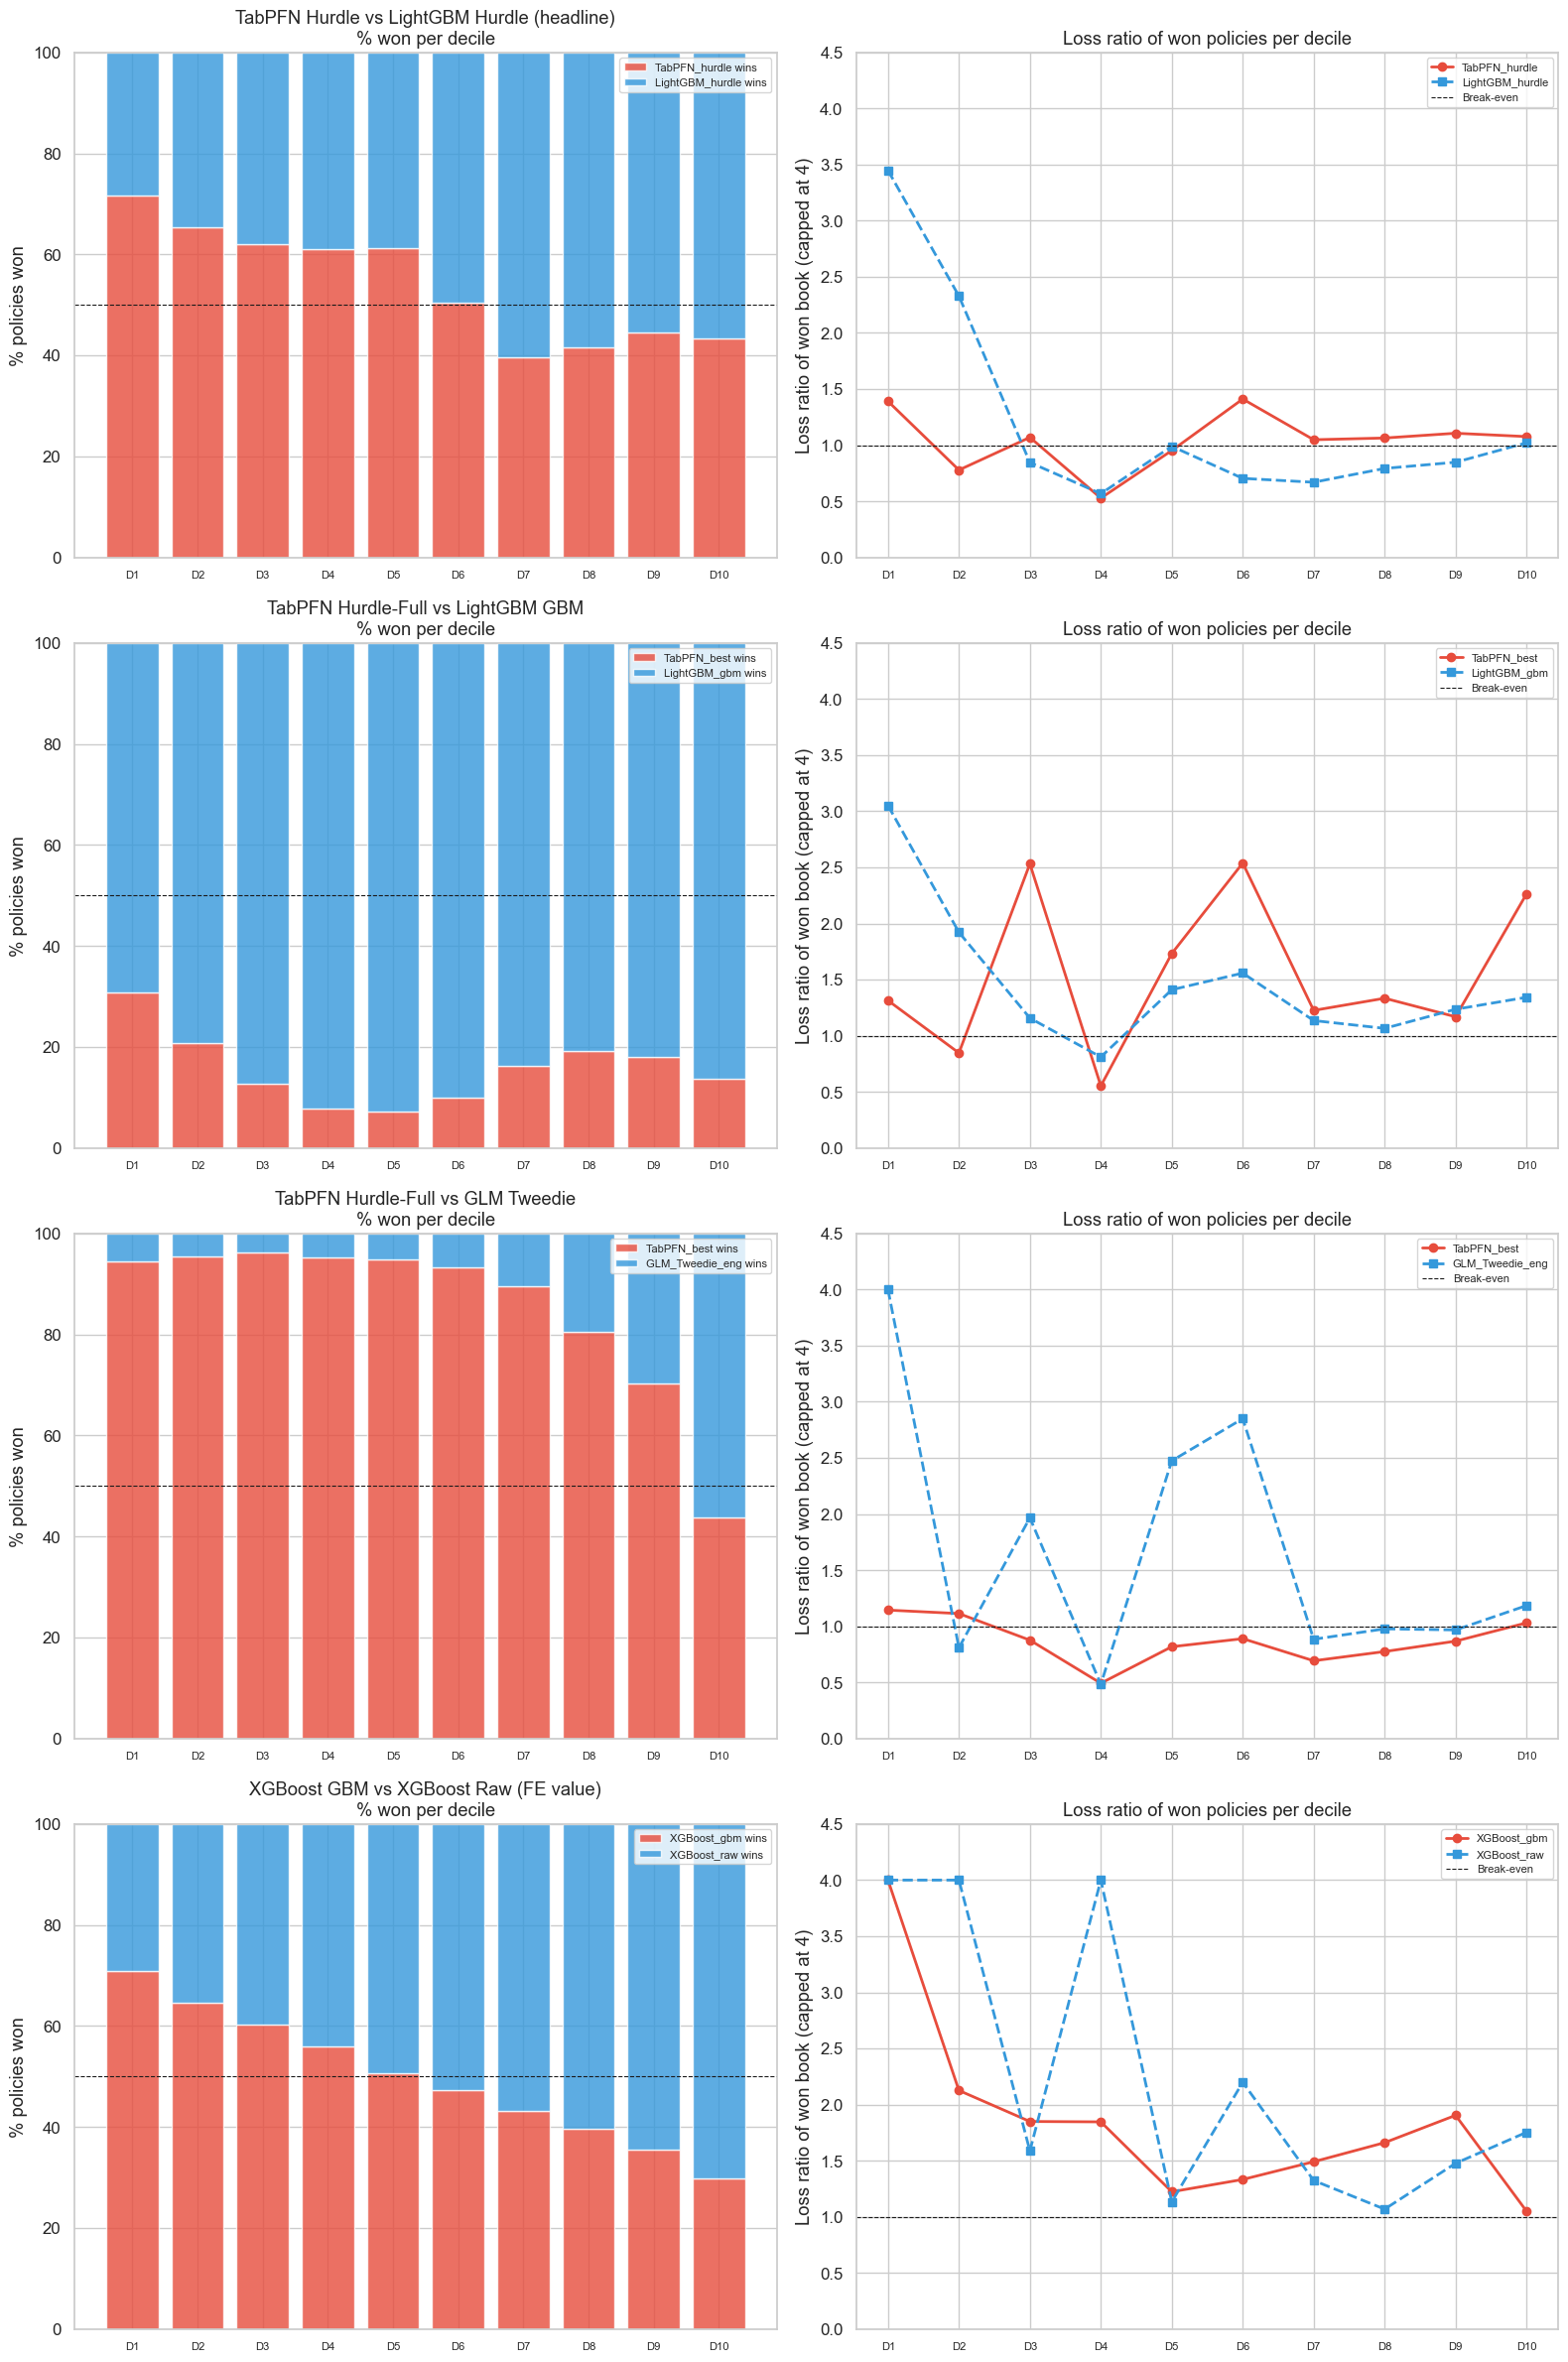

In [9]:
def plot_decile_auction(matchup_key, auction, title, ax_pct, ax_lr):
    """Plot two panels for a matchup: % policies won and loss ratio by decile."""
    decile_data = auction[matchup_key]['by_decile']
    agg = auction[matchup_key]['aggregate']
    name_a = agg['model_a']
    name_b = agg['model_b']

    deciles = [str(i) for i in range(1, 11)]
    a_pct = [decile_data['a_pct_policies'][d] * 100 for d in deciles]
    a_lr  = [decile_data['a_loss_ratio'][d] if decile_data['a_loss_ratio'][d] == decile_data['a_loss_ratio'][d]
              else np.nan for d in deciles]
    b_lr  = [decile_data['b_loss_ratio'][d] if decile_data['b_loss_ratio'][d] == decile_data['b_loss_ratio'][d]
              else np.nan for d in deciles]

    x = np.arange(10)
    ax_pct.bar(x, a_pct, color='#e74c3c', alpha=0.8, label=f'{name_a} wins')
    ax_pct.bar(x, [100 - p for p in a_pct], bottom=a_pct, color='#3498db', alpha=0.8, label=f'{name_b} wins')
    ax_pct.axhline(50, color='k', lw=0.8, ls='--')
    ax_pct.set_xticks(x)
    ax_pct.set_xticklabels([f'D{d}' for d in deciles], fontsize=8)
    ax_pct.set_ylabel('% policies won')
    ax_pct.set_title(f'{title}\n% won per decile')
    ax_pct.legend(fontsize=8)
    ax_pct.set_ylim(0, 100)

    a_lr_clean = [min(v, 4.0) if not np.isnan(v) else np.nan for v in a_lr]
    b_lr_clean = [min(v, 4.0) if not np.isnan(v) else np.nan for v in b_lr]

    ax_lr.plot(x, a_lr_clean, 'o-', color='#e74c3c', label=f'{name_a}', lw=2)
    ax_lr.plot(x, b_lr_clean, 's--', color='#3498db', label=f'{name_b}', lw=2)
    ax_lr.axhline(1.0, color='k', lw=0.8, ls='--', label='Break-even')
    ax_lr.set_xticks(x)
    ax_lr.set_xticklabels([f'D{d}' for d in deciles], fontsize=8)
    ax_lr.set_ylabel('Loss ratio of won book (capped at 4)')
    ax_lr.set_title('Loss ratio of won policies per decile')
    ax_lr.legend(fontsize=8)
    ax_lr.set_ylim(0, 4.5)


# Plot key matchups
matchups_to_plot = [
    ('TabPFN_hurdle_vs_LightGBM_hurdle', 'TabPFN Hurdle vs LightGBM Hurdle (headline)'),
    ('TabPFN_best_vs_LightGBM_gbm',      'TabPFN Hurdle-Full vs LightGBM GBM'),
    ('TabPFN_best_vs_GLM_Tweedie_eng',   'TabPFN Hurdle-Full vs GLM Tweedie'),
    ('XGBoost_gbm_vs_XGBoost_raw',       'XGBoost GBM vs XGBoost Raw (FE value)'),
]

fig, axes = plt.subplots(len(matchups_to_plot), 2, figsize=(16, 6 * len(matchups_to_plot)))

for i, (key, title) in enumerate(matchups_to_plot):
    if key in auction:
        plot_decile_auction(key, auction, title, axes[i, 0], axes[i, 1])

plt.tight_layout()
plt.savefig(FIGURES / 'auction_by_decile.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Summary aggregate auction table
agg_rows = []
for key, data in auction.items():
    agg = data['aggregate']
    agg_rows.append({
        'Matchup': f"{agg['model_a']} vs {agg['model_b']}",
        'A wins %': f"{agg['a_pct_policies']*100:.1f}%",
        'A avg risk': f"{agg['a_avg_actual_risk']:.1f}",
        'B avg risk': f"{agg['b_avg_actual_risk']:.1f}",
        'A loss ratio': f"{agg['a_loss_ratio']:.3f}",
        'B loss ratio': f"{agg['b_loss_ratio']:.3f}",
        'A profit €': f"{agg['a_profit']:+,.0f}",
        'B profit €': f"{agg['b_profit']:+,.0f}",
        'Winner': agg['model_a'] if agg['a_profit'] > agg['b_profit'] else agg['model_b'],
    })

agg_df = pd.DataFrame(agg_rows)
print("Auction Summary (aggregate over 135,603 holdout policies)")
display(agg_df)

Auction Summary (aggregate over 135,603 holdout policies)


,Matchup,A wins %,A avg risk,B avg risk,A loss ratio,B loss ratio,A profit €,B profit €,Winner
0,TabPFN_best vs LightGBM_gbm,15.6%,126.9,73.1,1.553,1.356,"-956,525","-2,196,837",TabPFN_best
1,TabPFN_hurdle vs LightGBM_hurdle,54.1%,91.2,70.2,1.032,0.988,"-208,601","+51,186",LightGBM_hurdle
2,TabPFN_best vs GLM_Tweedie_eng,85.4%,75.6,116.1,0.849,1.425,"+1,555,716","-686,557",TabPFN_best
3,XGBoost_gbm vs XGBoost_raw,49.8%,71.9,91.1,1.604,2.030,"-1,827,823","-3,147,232",XGBoost_gbm
4,TabPFN_hurdle vs TabPFN_10K_tweedie,0.0%,0.0,81.5,0.000,79.011,+509,"-10,915,765",TabPFN_hurdle
5,LightGBM_hurdle vs LightGBM_gbm,14.3%,123.2,74.6,1.579,1.317,"-878,090","-2,083,513",LightGBM_hurdle


## 7. Metric Disagreement Analysis (Enhanced)

Rank each model on every metric, show where rankings diverge — the 'benchmarks lie' finding.

In [11]:
# Build unified holdout metrics table (exclude catastrophic TabPFN direct Tweedie)
holdout_all = holdout_df  # baseline + all experiments (from the holdout-metrics cell)
holdout_clean = holdout_all[holdout_all['tweedie_dev_1.5'] < 1000].copy()

# Rank per metric (lower is better for deviance/RMSE/MAE, higher is better for Gini)
rank_df = pd.DataFrame(index=holdout_clean.index)
rank_df['Tweedie Dev rank']  = holdout_clean['tweedie_dev_1.5'].rank(ascending=True).astype(int)
rank_df['Poisson Dev rank']  = holdout_clean['poisson_dev'].rank(ascending=True).astype(int)
rank_df['Gini rank']         = holdout_clean['gini'].rank(ascending=False).astype(int)  # higher = better
rank_df['RMSE rank']         = holdout_clean['rmse'].rank(ascending=True).astype(int)
rank_df['MAE rank']          = holdout_clean['mae'].rank(ascending=True).astype(int)

rank_df['rank_std']   = rank_df.std(axis=1)
rank_df['rank_range'] = rank_df[['Tweedie Dev rank','Poisson Dev rank','Gini rank','RMSE rank','MAE rank']].max(axis=1) - \
                        rank_df[['Tweedie Dev rank','Poisson Dev rank','Gini rank','RMSE rank','MAE rank']].min(axis=1)

rank_df = rank_df.sort_values('Tweedie Dev rank')
print("Model rankings by metric (1=best). rank_range = max−min rank across metrics.")
display(rank_df.round(2))

Model rankings by metric (1=best). rank_range = max−min rank across metrics.


,Tweedie Dev rank,Poisson Dev rank,Gini rank,RMSE rank,MAE rank,rank_std,rank_range
model,,,,,,,
TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0,1,3,15,3,10,5.90,14
LightGBM_gbm_tweedie,2,1,6,2,6,2.41,5
TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6,3,4,16,5,11,5.54,13
LightGBM_raw_tweedie,4,2,8,10,5,3.19,8
TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6,5,5,2,11,4,3.36,9
TabPFN_10K_eng_tweedie@tabpfn_v3.0,6,9,3,4,13,4.06,10
LightGBM_hurdle_gbm_hurdle,7,6,12,6,12,3.13,6
LightGBM_engineered_tweedie,8,8,10,14,8,2.61,6
TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0,9,7,1,12,3,4.45,11


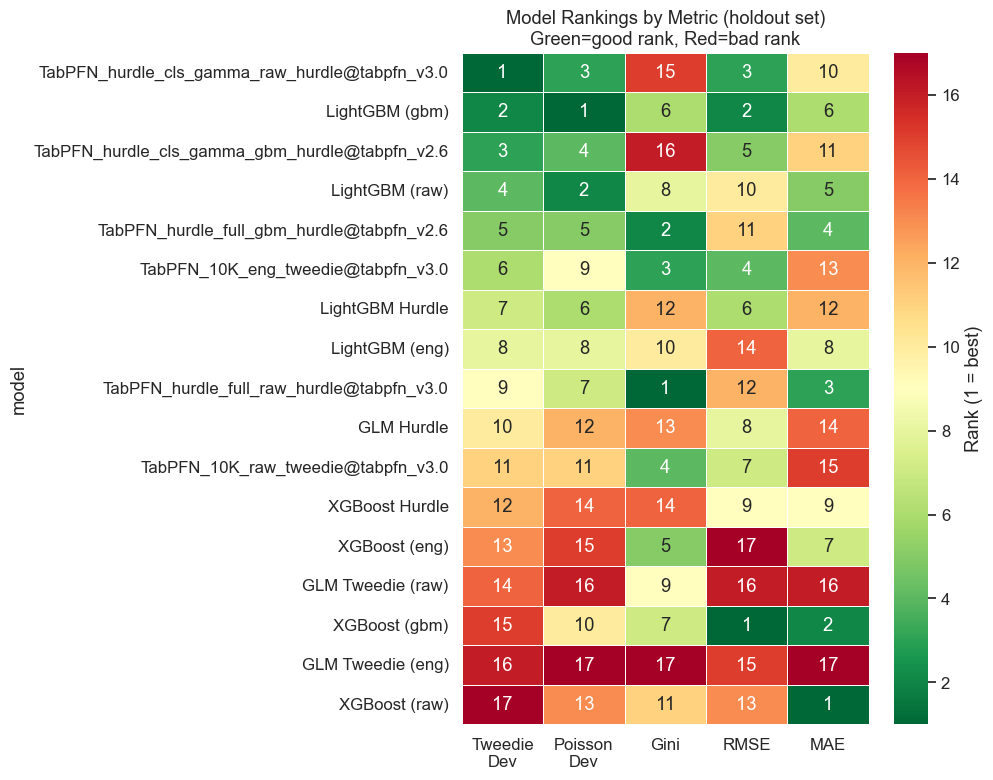

In [12]:
# Heatmap of metric ranks (sorted by Tweedie deviance rank)
rank_cols = ['Tweedie Dev rank','Poisson Dev rank','Gini rank','RMSE rank','MAE rank']

fig, ax = plt.subplots(figsize=(10, 8))

# Short model names for display
short_names = {
    'GLM_Tweedie_raw_tweedie': 'GLM Tweedie (raw)',
    'GLM_Tweedie_engineered_tweedie': 'GLM Tweedie (eng)',
    'XGBoost_raw_tweedie': 'XGBoost (raw)',
    'XGBoost_engineered_tweedie': 'XGBoost (eng)',
    'XGBoost_gbm_tweedie': 'XGBoost (gbm)',
    'XGBoost_hurdle_gbm_hurdle': 'XGBoost Hurdle',
    'LightGBM_raw_tweedie': 'LightGBM (raw)',
    'LightGBM_engineered_tweedie': 'LightGBM (eng)',
    'LightGBM_gbm_tweedie': 'LightGBM (gbm)',
    'LightGBM_hurdle_gbm_hurdle': 'LightGBM Hurdle',
    'GLM_hurdle_gbm_hurdle': 'GLM Hurdle',
    'TabPFN_hurdle_cls_gamma_gbm_hurdle': 'TabPFN Hurdle (cls+Gamma)',
    'TabPFN_hurdle_full_gbm_hurdle': 'TabPFN Hurdle (full)',
}

plot_df = rank_df[rank_cols].rename(index=lambda x: short_names.get(x, x))
plot_df.columns = ['Tweedie\nDev', 'Poisson\nDev', 'Gini', 'RMSE', 'MAE']

sns.heatmap(
    plot_df,
    annot=True, fmt='d', cmap='RdYlGn_r',
    vmin=1, vmax=len(plot_df),
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Rank (1 = best)'}
)
ax.set_title('Model Rankings by Metric (holdout set)\nGreen=good rank, Red=bad rank')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(FIGURES / 'metric_disagreement_heatmap_clean.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:

# Inspect raw holdout predictions for TabPFN direct Tweedie vs working models
all_preds = pd.read_parquet(RESULTS / 'holdout' / 'predictions_all.parquet')
print("Columns:", all_preds.columns.tolist())
print("Shape:", all_preds.shape)


from sklearn.metrics import mean_tweedie_deviance

# Load raw data to get y_true and exposure
data = pd.read_parquet('../data/insurance/processed.parquet')
holdout_idx = np.load('../data/insurance/holdout_idx.npy')
df_holdout = data.iloc[holdout_idx]
y_true = df_holdout['pure_premium'].values
exposure = df_holdout['Exposure'].values

print(f"Holdout: {len(y_true)} rows")
print(f"y_true stats: mean={y_true.mean():.4f}, median={np.median(y_true):.4f}, max={y_true.max():.2f}")
print(f"exposure stats: mean={exposure.mean():.4f}")

Columns: ['GLM_Tweedie_raw_tweedie', 'GLM_Tweedie_engineered_tweedie', 'XGBoost_raw_tweedie', 'XGBoost_engineered_tweedie', 'XGBoost_gbm_tweedie', 'LightGBM_raw_tweedie', 'LightGBM_engineered_tweedie', 'LightGBM_gbm_tweedie', 'GLM_hurdle_gbm_hurdle', 'XGBoost_hurdle_gbm_hurdle', 'LightGBM_hurdle_gbm_hurdle', 'TabPFN_10K_raw_tweedie@tabpfn_v2.6', 'TabPFN_10K_gbm_tweedie@tabpfn_v2.6', 'TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6', 'TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6', 'TabPFN_10K_raw_tweedie@tabpfn_v3.0', 'TabPFN_10K_eng_tweedie@tabpfn_v3.0', 'TabPFN_10K_uncalibrated_raw_tweedie@tabpfn_v3.0', 'TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0', 'TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0']
Shape: (135603, 20)
Holdout: 135603 rows
y_true stats: mean=290.6935, median=0.0000, max=4255057.11
exposure stats: mean=0.5279


In [24]:
# If we simply rescale TabPFN_10K predictions to match the portfolio mean,
# what deviance and Gini do we get?
# This is a lower bound on what recalibration (as spec'd) would achieve.
# Runs for every discovered experiment's TabPFN direct-Tweedie columns.

from sklearn.metrics import mean_tweedie_deviance

def gini_coefficient(y_true, y_pred):
    """Normalized Gini = 2*AUC-1 on sorted pairs."""
    df = pd.DataFrame({'y': y_true, 'p': y_pred}).sort_values('p')
    n = len(df)
    cum_y = df['y'].cumsum() / df['y'].sum()
    uniform = np.arange(1, n+1) / n
    return 1 - 2 * np.trapezoid(cum_y, uniform)

rescale_targets = [tag(m, exp) for exp in EXPERIMENTS
                   for m in ('TabPFN_10K_raw_tweedie', 'TabPFN_10K_gbm_tweedie')]
rescale_rows = []
for col_name in rescale_targets:
    if col_name not in all_preds.columns:
        continue
    preds = all_preds[col_name].values
    preds_clipped = np.clip(preds, 1e-6, np.inf)

    pred_mean = np.average(preds_clipped, weights=exposure)
    true_mean = np.average(y_true, weights=exposure)
    scale = true_mean / pred_mean

    preds_scaled = preds_clipped * scale

    dev_orig = mean_tweedie_deviance(y_true + 1e-9, preds_clipped + 1e-9, power=1.5, sample_weight=exposure)
    dev_scaled = mean_tweedie_deviance(y_true + 1e-9, preds_scaled + 1e-9, power=1.5, sample_weight=exposure)
    gini_orig = gini_coefficient(y_true, preds_clipped)
    gini_scaled = gini_coefficient(y_true, preds_scaled)  # Gini is rank-invariant — same

    rescale_rows.append({
        'model': col_name,
        'scale_factor': scale,
        'tweedie_original': dev_orig,
        'tweedie_rescaled': dev_scaled,
        'gini': gini_orig,
    })

rescale_df = pd.DataFrame(rescale_rows)
print("Post-hoc mean-rescaling of TabPFN direct Tweedie predictions:")
print("(This is a crude recalibration — spec called for Tweedie GLM or isotonic)")
display(rescale_df.round(4))


Post-hoc mean-rescaling of TabPFN direct Tweedie predictions:
(This is a crude recalibration — spec called for Tweedie GLM or isotonic)


,model,scale_factor,tweedie_original,tweedie_rescaled,gini
0,TabPFN_10K_raw_tweedie@tabpfn_v2.6,444.8966,590250.9371,27986.4768,0.0938
1,TabPFN_10K_gbm_tweedie@tabpfn_v2.6,78.6582,562071.7650,63398.6708,0.0897
2,TabPFN_10K_raw_tweedie@tabpfn_v3.0,0.6128,83.8021,80.5640,0.2320


## 9. Master Summary Table for Blog Post

In [27]:
# Final summary combining CV and holdout, with model family labels
# Only clean models (no catastrophic failures)

summary_rows = []
for model, row in holdout_clean.iterrows():
    cv_row = cv_summary.set_index('model').loc[model] if model in cv_summary.set_index('model').index else None
    summary_rows.append({
        'Model': short_names.get(model, model),
        'Family': model_family(model),
        'CV Tweedie': f"{cv_row['cv_tweedie_mean']:.2f} ± {cv_row['cv_tweedie_std']:.2f}" if cv_row is not None else '—',
        'Holdout Tweedie': f"{row['tweedie_dev_1.5']:.2f}",
        'Holdout Gini': f"{row['gini']:.4f}",
        'Holdout RMSE': f"{row['rmse']:.1f}",
        'Holdout MAE': f"{row['mae']:.1f}",
        'Approach': 'Hurdle' if 'hurdle' in model.lower() else 'Direct Tweedie',
        'Is TabPFN': 'TabPFN' in model,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Holdout Tweedie')

print("MASTER RESULTS TABLE (holdout, sorted by Tweedie deviance)")
print("Note: TabPFN_10K direct-Tweedie models excluded — catastrophic holdout failure.")
display(summary_df.drop(columns=['Is TabPFN']))

MASTER RESULTS TABLE (holdout, sorted by Tweedie deviance)
Note: TabPFN_10K direct-Tweedie models excluded — catastrophic holdout failure.


,Model,Family,CV Tweedie,Holdout Tweedie,Holdout Gini,Holdout RMSE,Holdout MAE,Approach
15,TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0,TabPFN,82.75 ± 1.98,81.72,0.0541,6238.6,307.3,Hurdle
7,LightGBM (gbm),LightGBM,79.55 ± 2.73,82.00,0.1505,6238.0,259.4,Direct Tweedie
11,TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6,TabPFN,82.92 ± 2.31,82.06,0.0432,6238.7,317.0,Hurdle
5,LightGBM (raw),LightGBM,80.09 ± 2.30,82.29,0.1274,6239.5,259.1,Direct Tweedie
12,TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6,TabPFN,81.22 ± 3.92,82.77,0.4062,6240.5,257.3,Hurdle
14,TabPFN_10K_eng_tweedie@tabpfn_v3.0,TabPFN,—,82.78,0.2892,6238.6,367.9,Direct Tweedie
10,LightGBM Hurdle,LightGBM,81.56 ± 1.99,82.88,0.0815,6238.8,324.1,Hurdle
16,TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0,TabPFN,80.68 ± 3.17,83.13,0.4252,6241.1,251.2,Hurdle
6,LightGBM (eng),LightGBM,83.63 ± 3.95,83.13,0.0881,6246.5,265.9,Direct Tweedie
8,GLM Hurdle,GLM,85.16 ± 2.21,83.78,0.0787,6239.0,372.8,Hurdle
